**Customer Segmentation Project-Thiranex**

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [5]:
df = pd.read_excel("/content/Online Retail.xlsx")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [7]:
#Data Cleaning
df = df.dropna(subset=['CustomerID'])

df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

print(df.shape)

(397884, 9)


In [8]:
#Create RFM Features
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalAmount': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

print(rfm.head())

            Recency  Frequency  Monetary
CustomerID                              
12346.0         326          1  77183.60
12347.0           2          7   4310.00
12348.0          75          4   1797.24
12349.0          19          1   1757.55
12350.0         310          1    334.40


In [9]:
#Feature Scaling
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

In [10]:
#Apply K-Means
kmeans = KMeans(n_clusters=4, random_state=42)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

print(rfm.head())

            Recency  Frequency  Monetary  Cluster
CustomerID                                       
12346.0         326          1  77183.60        3
12347.0           2          7   4310.00        0
12348.0          75          4   1797.24        0
12349.0          19          1   1757.55        0
12350.0         310          1    334.40        1


In [12]:
#Customer Count in Each Cluster
cluster_counts = rfm['Cluster'].value_counts()

print(cluster_counts)

print(rfm['Cluster'].value_counts())

Cluster
0    3054
1    1067
3     204
2      13
Name: count, dtype: int64
Cluster
0    3054
1    1067
3     204
2      13
Name: count, dtype: int64


In [13]:
#Cluster Summary
summary = rfm.groupby('Cluster').mean()

print(summary)

            Recency  Frequency       Monetary
Cluster                                      
0         43.702685   3.682711    1359.049284
1        248.075914   1.552015     480.617480
2          7.384615  82.538462  127338.313846
3         15.500000  22.333333   12709.090490


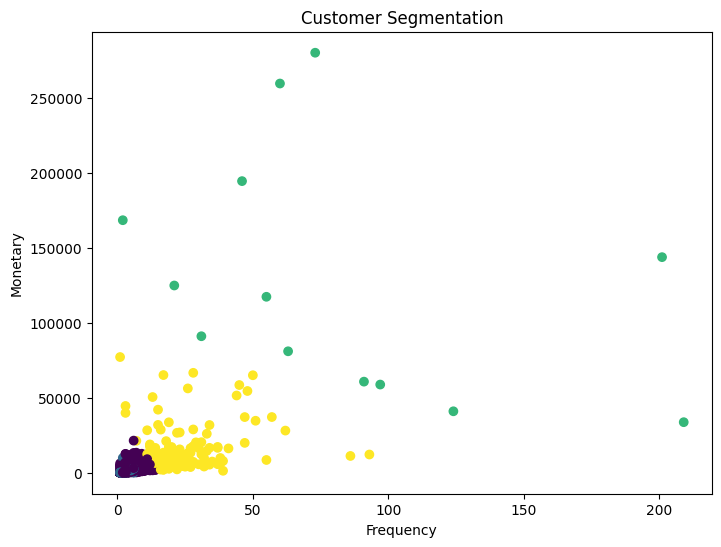

In [14]:
#Visualization
plt.figure(figsize=(8,6))

plt.scatter(
    rfm['Frequency'],
    rfm['Monetary'],
    c=rfm['Cluster']
)

plt.xlabel("Frequency")
plt.ylabel("Monetary")
plt.title("Customer Segmentation")

plt.show()

In [15]:
#Save Results
rfm.to_csv("Customer_Segmentation_Result.csv")